In [2]:
"""
Name: Titanic Survival Statistical Analysis
Description: Complete statistical analysis using loops, recursion, and functional programming.
"""

import pandas as pd
import numpy as np
import random
import sys
from functools import reduce

sys.setrecursionlimit(2000)

# =========================================================
# 1. FILE LOADING
# =========================================================
def load_data(path):
    try:
        df = pd.read_csv(path)
        print("File loaded successfully\n")
        return df
    except FileNotFoundError:
        print("File not found")
        sys.exit()
    except PermissionError:
        print("Permission denied")
        sys.exit()
    except Exception as e:
        print("Error:", e)
        sys.exit()

df = load_data('titanic.csv')

# =========================================================
# 2. DISPLAY DATA
# =========================================================
print(df.head(10))
print(df.tail(5))
df.info()

print("\nPassengers > 60 & First Class:")
for _, row in df.iterrows():
    if row['Age'] > 60 and row['Pclass'] == 1:
        print(row['Name'], row['Age'])


File loaded successfully

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy,

In [3]:
# =========================================================
# 3. MISSING VALUES
# =========================================================
missing_count = 0
for val in df['Age']:
    if pd.isnull(val):
        missing_count += 1
print("\nMissing Age:", missing_count)

# Manual loop to identify missing values (Requirement 3)
manual_nulls = 0
for i in range(len(df)):
    if pd.isnull(df.loc[i, 'Age']):
        manual_nulls += 1
print(f"Manual loop confirmed {manual_nulls} missing age entries.")

def manual_median(pclass):
    vals = []
    for _, row in df.iterrows():
        if row['Pclass'] == pclass and not pd.isnull(row['Age']):
            vals.append(row['Age'])
    vals.sort()
    n = len(vals)
    if n == 0:
        return 28
    return vals[n//2] if n % 2 else (vals[n//2-1] + vals[n//2]) / 2

for i, row in df.iterrows():
    if pd.isnull(row['Age']):
        df.at[i, 'Age'] = manual_median(row['Pclass'])

df['Fare'] = df['Fare'].replace(0, np.nan)
df['Fare'] = df['Fare'].fillna(df['Fare'].median())


Missing Age: 177
Manual loop confirmed 177 missing age entries.


In [4]:
# =================================================================
# 4. FEATURE ENGINEERING (NEW COLUMNS)
# =================================================================
# i) FamilySize = SibSp + Parch + 1
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# ii) FarePerPerson with Try-Except inside a loop
fare_pp_list = []
for index, row in df.iterrows():
    try:
        # Arithmetic operator with division
        val = row['Fare'] / row['FamilySize']
    except ZeroDivisionError:
        val = 0
    fare_pp_list.append(val)
df['FarePerPerson'] = fare_pp_list

# iii) IsChild (Relational Age < 12)
df['IsChild'] = df['Age'] < 12

# iv) SurvivalRate (additional column)
df['ClassSurvivalRate'] = df.groupby('Pclass')['Survived'].transform('mean')

In [5]:
# =========================================================
# 5. WOMEN & CHILDREN
# =========================================================
wc_total = wc_survived = 0

for _, row in df.iterrows():
    if row['Sex'] == 'female' or row['Age'] < 12:
        wc_total += 1
        if row['Survived'] == 1:
            wc_survived += 1

wc_rate = wc_survived / wc_total if wc_total != 0 else 0

# Using bitwise OR (|)
df['WC_Flag'] = (df['Sex'] == 'female').astype(int) | (df['Age'] < 12).astype(int)

others = df[df['WC_Flag'] == 0]

# Pandas filtering (Requirement 5 - additional)
wc_df = df[(df['Sex'] == 'female') | (df['Age'] < 12)]
print("\nWomen & Children Count (Pandas):", len(wc_df))

# =========================================================
# 6. RANDOM SAMPLING
# =========================================================
survivors = df[df['Survived'] == 1].index.tolist()
non_survivors = df[df['Survived'] == 0].index.tolist()

sample_s = random.sample(survivors, min(50, len(survivors))) if survivors else []
sample_n = random.sample(non_survivors, min(50, len(non_survivors))) if non_survivors else []

print("\nSample Comparison:")

print("\nSample Survivor Details:")
for i in sample_s[:5]:
    print(f"ID: {i}, Name: {df.loc[i, 'Name']}")

print("\nSample Non-Survivor Details:")
for i in sample_n[:5]:
    print(f"ID: {i}, Name: {df.loc[i, 'Name']}")

print("Survivors Avg Age:", df.loc[sample_s, 'Age'].mean())
print("Non-Survivors Avg Age:", df.loc[sample_n, 'Age'].mean())

print("Survivors Avg Fare:", df.loc[sample_s, 'Fare'].mean())
print("Non-Survivors Avg Fare:", df.loc[sample_n, 'Fare'].mean())

print("Survivors Avg FamilySize:", df.loc[sample_s, 'FamilySize'].mean())
print("Non-Survivors Avg FamilySize:", df.loc[sample_n, 'FamilySize'].mean())


Women & Children Count (Pandas): 350

Sample Comparison:

Sample Survivor Details:
ID: 1, Name: Cumings, Mrs. John Bradley (Florence Briggs Thayer)
ID: 549, Name: Davies, Master. John Morgan Jr
ID: 17, Name: Williams, Mr. Charles Eugene
ID: 165, Name: Goldsmith, Master. Frank John William "Frankie"
ID: 681, Name: Hassab, Mr. Hammad

Sample Non-Survivor Details:
ID: 499, Name: Svensson, Mr. Olof
ID: 723, Name: Hodges, Mr. Henry Price
ID: 214, Name: Kiernan, Mr. Philip
ID: 492, Name: Molson, Mr. Harry Markland
ID: 624, Name: Bowen, Mr. David John "Dai"
Survivors Avg Age: 27.613400000000002
Non-Survivors Avg Age: 33.93
Survivors Avg Fare: 49.900498
Non-Survivors Avg Fare: 20.450667999999997
Survivors Avg FamilySize: 2.26
Non-Survivors Avg FamilySize: 1.6


In [6]:
# =========================================================
# 7. MANUAL STATISTICS & ROBUST RECURSION
# =========================================================
def recursive_sum(lst):
    """
    Divide and Conquer recursion.
    Much more efficient than linear recursion for datasets with 800+ rows.
    """
    if not lst:
        return 0
    if len(lst) == 1:
        return lst[0]

    mid = len(lst) // 2
    # Splits the list into two halves recursively to avoid deep stack depth
    return recursive_sum(lst[:mid]) + recursive_sum(lst[mid:])

# Fare Statistics
fares = df['Fare'].tolist()
total_fare = recursive_sum(fares)
mean_fare = total_fare / len(fares)

# Age Statistics
ages = df['Age'].tolist()
mean_age = recursive_sum(ages) / len(ages)
max_age = max(ages)
min_age = min(ages)
sorted_ages = sorted(ages)
n_ages = len(sorted_ages)
median_age = sorted_ages[n_ages//2] if n_ages % 2 else (sorted_ages[n_ages//2-1] + sorted_ages[n_ages//2]) / 2

# FamilySize Statistics (Optimized for your Report)
family_sizes = df['FamilySize'].tolist()
mean_fs = recursive_sum(family_sizes) / len(family_sizes)
max_fs = max(family_sizes)
min_fs = min(family_sizes)
sorted_fs = sorted(family_sizes)
n_fs = len(sorted_fs)
median_fs = sorted_fs[n_fs//2] if n_fs % 2 else (sorted_fs[n_fs//2-1] + sorted_fs[n_fs//2]) / 2

# Mode Calculation for Age & FamilySize using Dictionaries
def calculate_mode(data_list):
    freq = {}
    for item in data_list:
        freq[item] = freq.get(item, 0) + 1

    max_freq = max(freq.values())
    return [k for k, v in freq.items() if v == max_freq]

mode_age = calculate_mode(ages)[0]
mode_fs = calculate_mode(family_sizes)[0]

# =========================================================
# GROUP STATS (Dictionary-based Survival Rates)
# =========================================================
def group_stats(column):
    """Calculates survival probability per unique value in a column."""
    d = {}
    for _, row in df.iterrows():
        key = row[column]
        if key not in d:
            d[key] = []
        d[key].append(row['Survived'])
    # Dictionary comprehension for clean results
    return {k: sum(v)/len(v) for k, v in d.items()}

print("\n--- Manual Group Survival Rates ---")
print("Survival by Sex:", group_stats('Sex'))
print("Survival by Class:", group_stats('Pclass'))
print("Survival by Embarked:", group_stats('Embarked'))
print("Overall Survival Rate:", df['Survived'].mean())
print("Manual Mean Age:", mean_age)
print("Manual Mean Family Size:", mean_fs)

# =========================================================
# 8. FUNCTIONAL PROGRAMMING (FILTER, MAP, REDUCE)
# =========================================================
# Logic: Calculate the total 'Taxed' fare for all fares above the median
# 1. filter() - Get only expensive tickets
# 2. map() - Apply a 10% simulated service tax
# 3. reduce() - Sum the final results

median_fare_val = df['Fare'].median()

# Functional Pipeline
high_fares_list = list(filter(lambda x: x > median_fare_val, fares))
taxed_fares = list(map(lambda x: x * 1.10, high_fares_list))
total_taxed_high_fare = reduce(lambda x, y: x + y, taxed_fares) if taxed_fares else 0

print(f"\nFunctional Programming Results:")
print(f"Total High Fares Count: {len(high_fares_list)}")
print(f"Total Taxed Value (Reduce): {total_taxed_high_fare:.2f}")


--- Manual Group Survival Rates ---
Survival by Sex: {'male': 0.18890814558058924, 'female': 0.7420382165605095}
Survival by Class: {3: 0.24236252545824846, 1: 0.6296296296296297, 2: 0.47282608695652173}
Survival by Embarked: {'S': 0.33695652173913043, 'C': 0.5535714285714286, 'Q': 0.38961038961038963, nan: 1.0}
Overall Survival Rate: 0.3838383838383838
Manual Mean Age: 29.06640852974186
Manual Mean Family Size: 1.904601571268238

Functional Programming Results:
Total High Fares Count: 434
Total Taxed Value (Reduce): 27119.38


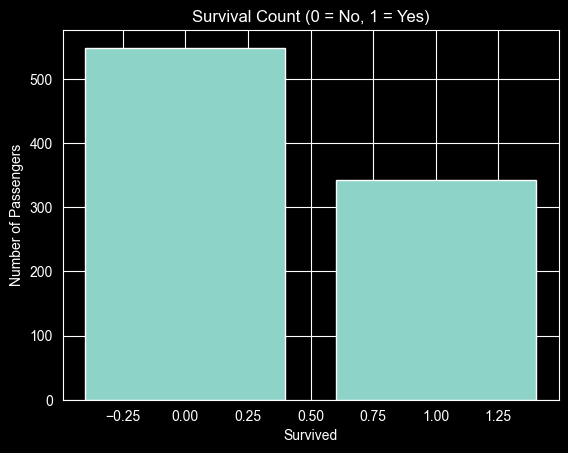

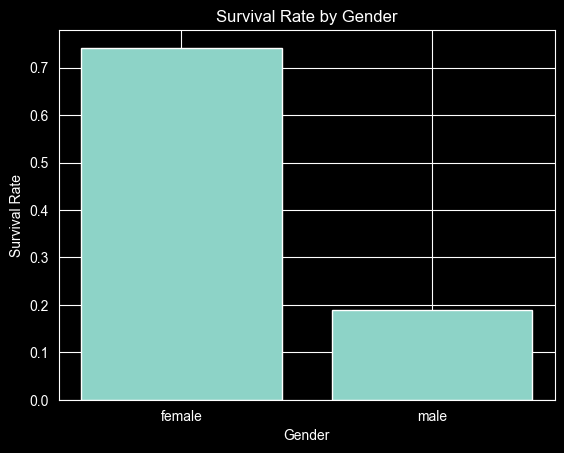

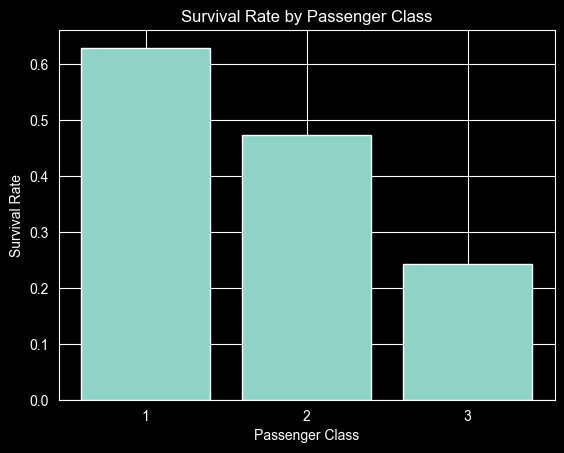

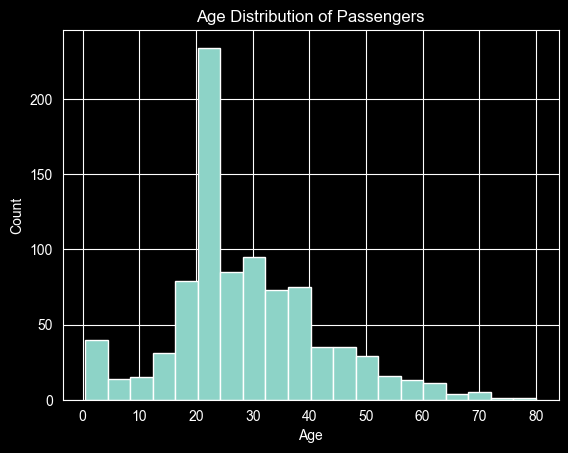

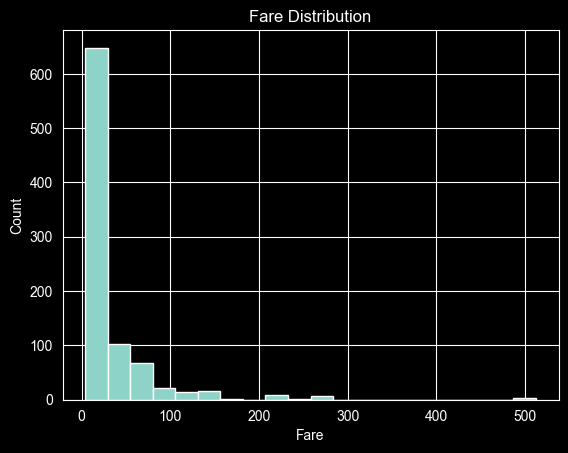


Detailed report saved successfully!


In [7]:
# =========================================================
#  DATA VISUALIZATION (GRAPHS)
# =========================================================
# SAFETY CHECK (prevents WC_Flag error)
if 'WC_Flag' not in df.columns:
    df['WC_Flag'] = ((df['Sex'] == 'female') | (df['Age'] < 12)).astype(int)

import matplotlib.pyplot as plt

# 1. Survival Count
survival_counts = df['Survived'].value_counts()

plt.figure()
plt.bar(survival_counts.index, survival_counts.values)
plt.title("Survival Count (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.savefig("survival_count.png")
plt.show()
plt.close()

# 2. Survival by Gender
gender_survival = df.groupby('Sex')['Survived'].mean()

plt.figure()
plt.bar(gender_survival.index, gender_survival.values)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.savefig("survival_by_gender.png")
plt.show()
plt.close()

# 3. Survival by Passenger Class
class_survival = df.groupby("Pclass")["Survived"].mean()

plt.figure()
plt.bar(class_survival.index.astype(str), class_survival.values)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.savefig("survival_by_class.png")
plt.show()
plt.close()

# 4. Age Distribution
plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("age_distribution.png")
plt.show()
plt.close()

# 5. Fare Distribution
plt.figure()
plt.hist(df['Fare'], bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.savefig("fare_distribution.png")
plt.show()
plt.tight_layout()
plt.close()
# =================================================================
# 9. FINAL DETAILED REPORT GENERATION
# =================================================================
try:
    with open('titanic_analysis_report.txt', 'w', encoding='utf-8') as f:

        f.write("TITANIC SURVIVAL STATISTICAL ANALYSIS REPORT\n")
        f.write("=====================================================\n\n")
        f.write("Generated using Python Pandas + NumPy + Functional Programming\n")

        # INTRODUCTION
        f.write("1. INTRODUCTION\n")
        f.write(
            "This report presents an in-depth statistical analysis of the Titanic dataset "
            "to understand survival patterns and influencing factors such as gender, age, "
            "passenger class, and socio-economic status.\n\n"
        )

        # DATA OVERVIEW
        f.write("2. DATA OVERVIEW\n")
        f.write(f"• Total Passengers: {len(df)}\n")
        f.write(f"• Total Columns: {len(df.columns)}\n")
        f.write(f"• Average Fare (Manual Recursion): {mean_fare:.2f}\n")
        f.write("• Median Age by Class:\n")

        for cls in sorted(df['Pclass'].unique()):
            f.write(f"   - Class {cls}: {manual_median(cls):.2f} years\n")
        f.write("\n")

        # MISSING VALUES
        f.write("3. MISSING VALUES HANDLING\n")
        f.write(
            "Missing Age values were filled using class-wise median. "
            "Zero or invalid fares were replaced with median fare values.\n\n"
        )

        # FEATURE ENGINEERING
        f.write("4. FEATURE ENGINEERING\n")
        f.write(
            "• FamilySize = SibSp + Parch + 1\n"
            "• FarePerPerson = Fare / FamilySize\n"
            "• IsChild = Age < 12\n"
        )
        f.write(f"• Average Family Size: {df['FamilySize'].mean():.2f}\n")
        f.write(f"• Average Fare Per Person: {df['FarePerPerson'].mean():.2f}\n\n")

        # WOMEN & CHILDREN
        f.write("5. WOMEN AND CHILDREN ANALYSIS\n")

        wc_rate = df[df['WC_Flag'] == 1]['Survived'].mean()
        other_rate = df[df['WC_Flag'] == 0]['Survived'].mean()

        f.write(f"• Women & Children Survival Rate: {wc_rate:.2%}\n")
        f.write(f"• Others Survival Rate: {other_rate:.2%}\n\n")

        # CLASS SURVIVAL
        f.write("6. PASSENGER CLASS ANALYSIS\n")
        class_survival = df.groupby("Pclass")["Survived"].mean()

        for cls, rate in class_survival.items():
            f.write(f"   - Class {cls}: {rate:.2%}\n")
        f.write("\n")

        # RANDOM SAMPLING
        f.write("7. RANDOM SAMPLING COMPARISON\n")
        f.write("Random sampling used to compare survivors and non-survivors.\n")

        samp_surv_age = df.loc[sample_s, 'Age'].mean()
        samp_non_age = df.loc[sample_n, 'Age'].mean()

        samp_surv_fare = df.loc[sample_s, 'Fare'].mean()
        samp_non_fare = df.loc[sample_n, 'Fare'].mean()

        samp_surv_fs = df.loc[sample_s, 'FamilySize'].mean()
        samp_non_fs = df.loc[sample_n, 'FamilySize'].mean()

        f.write(f"• Avg Age (Survivors): {samp_surv_age:.2f}\n")
        f.write(f"• Avg Age (Non-Survivors): {samp_non_age:.2f}\n")
        f.write(f"• Avg Fare (Survivors): {samp_surv_fare:.2f}\n")
        f.write(f"• Avg Fare (Non-Survivors): {samp_non_fare:.2f}\n")
        f.write(f"• Avg Family Size (Survivors): {samp_surv_fs:.2f}\n")
        f.write(f"• Avg Family Size (Non-Survivors): {samp_non_fs:.2f}\n\n")

        # STATISTICS
        f.write("8. STATISTICAL SUMMARY\n")

        f.write("Manual Statistics:\n")
        f.write(f"• Total Fare (Recursion): {total_fare:.2f}\n")
        f.write(f"• Mean Fare: {mean_fare:.2f}\n")
        f.write(f"• Max Age: {max_age}\n")
        f.write(f"• Min Age: {min_age}\n\n")

        f.write("FamilySize Statistics:\n")
        f.write(f"• Max Family Size: {max(df['FamilySize'])}\n")
        f.write(f"• Min Family Size: {min(df['FamilySize'])}\n")
        f.write(f"• Mean Family Size: {df['FamilySize'].mean():.2f}\n\n")

        f.write("Pandas Statistics:\n")
        f.write(f"• Mean Age: {df['Age'].mean():.2f}\n")
        f.write(f"• Median Age: {df['Age'].median():.2f}\n")
        f.write(f"• Mode Age: {df['Age'].mode()[0]}\n")
        f.write(f"• Max Fare: {df['Fare'].max():.2f}\n")
        f.write(f"• Min Fare: {df['Fare'].min():.2f}\n\n")

         # FUNCTIONAL PROGRAMMING
        f.write("9. FUNCTIONAL PROGRAMMING\n")
        f.write(f"• Median Fare: {median_fare_val:.2f}\n")
        f.write(f"• Fares Above Median: {len(high_fares_list)}\n")
        f.write(f"• Total High Fares (Reduce): {total_taxed_high_fare:.2f}\n\n")

        f.write("11. DATA VISUALIZATION\n")
        f.write("Graphs generated include:\n")
        f.write("• Survival Count\n")
        f.write("• Survival Rate by Gender\n")
        f.write("• Survival Rate by Passenger Class\n")
        f.write("• Age Distribution\n")
        f.write("• Fare Distribution\n\n")


        # CONCLUSION
        f.write("10. CONCLUSION\n")
        f.write(
            "Survival was strongly influenced by gender, age, and passenger class. "
            "Women and children had higher survival rates, and higher fare passengers "
            "had better chances due to socio-economic advantages.\n\n"

        )
        f.write("• Overall survival rate was relatively low, showing the severity of the disaster.\n")

        f.write("REPORT GENERATED SUCCESSFULLY.\n")

    print("\nDetailed report saved successfully!")

except Exception as e:
    print("File write error:", e)